# Mini Projet — Partie 1 : Data Process + Data Visualization
## « L'Afrique de l'Ouest est-elle bien desservie par le transport aérien ? »

**UE FDIA — Traitement de données avec Python** | CITADEL / UVBF

---

### Objectif

Ce projet combine deux compétences vues en cours :
- **Phase A (Data Process)** : import, nettoyage, filtrage et extraction de données avec Pandas (séquences 1 à 7 et 12).
- **Phase B (Data Visualization)** : transformer un résultat de la Phase A en une communication explicative claire, en appliquant les principes du cours (contexte Who/What/How, choix du graphique, élimination du clutter).

### Données

Source ouverte et accessible : [OurAirports](https://ourairports.com/data/), base mondiale des aéroports, mise à jour quotidiennement.

```
URL = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"
```

### Consignes générales

- Complétez toutes les cellules marquées `# TODO` ou `*(à compléter)*`.
- Ne supprimez pas les cellules de justification Markdown : elles font partie de l'évaluation.
- Le notebook doit pouvoir être exécuté de haut en bas sans erreur (`Restart & Run All`).
- Committez votre travail progressivement sur GitHub (un seul commit final = pénalité).

### Rendu attendu

1. Ce notebook complété (Jupyter ou Google Colab), code et sorties visibles.
2. Un dépôt GitHub `mini_projet_data_dataviz_partie1` contenant : ce notebook, les fichiers CSV produits, l'image du graphique final, et un fichier `storyboard.md`.


---
# Étape 0 — Identification et individualisation des paramètres

Chaque étudiant reçoit un **sous-ensemble de pays** et un **scénario de communication** différents, déterminés automatiquement à partir de votre matricule. Cela garantit que chaque projet repose sur des données et un contexte propres à vous.

**Remplacez `MATRICULE` ci-dessous par votre matricule étudiant, puis exécutez la cellule.**


In [18]:
import hashlib

MATRICULE = "n00084220051"  # TODO : n00084220051

REGIONS = {
    0: ("Afrique de l'Ouest", ["BF", "ML", "NE", "SN", "CI", "GH", "NG", "TG", "BJ", "GN"]),
    1: ("Afrique de l'Est", ["KE", "TZ", "UG", "ET", "RW", "SO", "DJ", "BI"]),
    2: ("Afrique australe", ["ZA", "ZW", "ZM", "BW", "NA", "MZ", "MW"]),
    3: ("Amérique centrale", ["GT", "HN", "SV", "NI", "CR", "PA", "BZ"]),
    4: ("Asie du Sud-Est", ["TH", "VN", "KH", "LA", "MM", "PH", "ID", "MY"]),
    5: ("Europe de l'Est", ["PL", "CZ", "SK", "HU", "RO", "BG", "UA"]),
}

SCENARIOS = {
    0: ("A", "Comité d'investissement régional (ex. BOAD)",
        "Justifier un investissement dans un pays sous-desservi de votre échantillon"),
    1: ("B", "Grand public, via un article de blog",
        "Sensibiliser sur les inégalités d'accès au transport aérien dans votre échantillon"),
    2: ("C", "Compagnie aérienne low-cost",
        "Identifier une opportunité de marché : un pays sans grand aéroport actif"),
}

assert MATRICULE != "A_COMPLETER", "Renseignez votre matricule avant de continuer."

seed = int(hashlib.sha256(MATRICULE.encode()).hexdigest(), 16)
region_id = seed % len(REGIONS)
scenario_id = (seed // len(REGIONS)) % len(SCENARIOS)

region_name, region_countries = REGIONS[region_id]
scenario_code, scenario_who, scenario_what = SCENARIOS[scenario_id]

print(f"Région assignée   : {region_name} {region_countries}")
print(f"Scénario assigné  : {scenario_code}")
print(f"  Who (audience)  : {scenario_who}")
print(f"  What (message)  : {scenario_what}")


Région assignée   : Afrique de l'Est ['KE', 'TZ', 'UG', 'ET', 'RW', 'SO', 'DJ', 'BI']
Scénario assigné  : B
  Who (audience)  : Grand public, via un article de blog
  What (message)  : Sensibiliser sur les inégalités d'accès au transport aérien dans votre échantillon


---
# PHASE A — Data Process

## A.1 — Import des données


In [19]:
import pandas as pd

URL = "https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"

# TODO : importer le CSV avec pandas
df = pd.read_csv(URL) # votre code ici
print(df.shape)
df.head()


(85614, 19)


,id,ident,type,name,latitude_deg,longitude_deg,elevation_ft,continent,iso_country,iso_region,municipality,scheduled_service,icao_code,iata_code,gps_code,local_code,home_link,wikipedia_link,keywords
0,6523,00A,heliport,Total RF Heliport,40.070985,-74.933689,11.0,NaN,US,US-PA,Bensalem,no,NaN,NaN,K00A,00A,https://www.penndot.pa.gov/TravelInPA/airports...,NaN,NaN
1,323361,00AA,small_airport,Aero B Ranch Airport,38.704022,-101.473911,3435.0,NaN,US,US-KS,Leoti,no,NaN,NaN,00AA,00AA,NaN,NaN,NaN
2,6524,00AK,small_airport,Lowell Field,59.947733,-151.692524,450.0,NaN,US,US-AK,Anchor Point,no,NaN,NaN,00AK,00AK,NaN,NaN,NaN
3,6525,00AL,small_airport,Epps Airpark,34.864799,-86.770302,820.0,NaN,US,US-AL,Harvest,no,NaN,NaN,00AL,00AL,NaN,NaN,NaN
4,506791,00AN,small_airport,Katmai Lodge Airport,59.093287,-156.456699,80.0,NaN,US,US-AK,King Salmon,no,NaN,NaN,00AN,00AN,NaN,NaN,NaN


## A.2 — Prétraitement

- Ne garder que les colonnes utiles : `ident`, `name`, `type`, `iso_country`, `latitude_deg`, `longitude_deg`, `elevation_ft`, `scheduled_service`.
- Renommer respectivement en : `ID`, `airport_name`, `type`, `country`, `lat`, `long`, `elevation`, `service`.


In [20]:
# TODO : ne garder que les colonnes utiles :
print(df.shape)
df = df[["ident", "name", "type", "iso_country","latitude_deg", "longitude_deg", "elevation_ft", "scheduled_service"]]



# TODO : renommer ces colonnes respectivement en :
#        ID, airport_name, type, country, lat, long, elevation, service

df = df.rename(columns={
    "ident": "ID",
    "name": "airport_name",
    "type": "type",
    "iso_country": "country",
    "latitude_deg": "lat",
    "longitude_deg": "long",
    "elevation_ft": "elevation",
    "scheduled_service": "service",
})

df.head()


(85614, 19)


,ID,airport_name,type,country,lat,long,elevation,service
0,00A,Total RF Heliport,heliport,US,40.070985,-74.933689,11.0,no
1,00AA,Aero B Ranch Airport,small_airport,US,38.704022,-101.473911,3435.0,no
2,00AK,Lowell Field,small_airport,US,59.947733,-151.692524,450.0,no
3,00AL,Epps Airpark,small_airport,US,34.864799,-86.770302,820.0,no
4,00AN,Katmai Lodge Airport,small_airport,US,59.093287,-156.456699,80.0,no


### Traitement des valeurs manquantes

Le dataset réel contient des valeurs manquantes dans `elevation`. Identifiez-les puis choisissez et **justifiez** une stratégie de traitement.


In [ ]:
# TODO : combien de valeurs manquantes dans 'elevation' ?
nb_nan = df["elevation"].isnull().sum()
print(f"Valeurs manquantes dans 'elevation' : {nb_nan} sur {len(df)} lignes")

# TODO : appliquez votre stratégie de traitement (suppression, valeur par défaut, conservation...) On ne supprime rien on s'assure juste que le champ elevation est numerique.
# Je perdrais de l'information utile pour traiter cette colonne.
# Garder Nan pourrait fausser certains calculs statistiques
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")

Valeurs manquantes dans 'elevation' : 14852 sur 85614 lignes


**Justification de la stratégie choisie :** *(à compléter — pourquoi cette approche plutôt qu'une autre ? quel impact sur la suite de l'analyse ?)*


In [30]:
df.to_csv("airports_clean.csv", index=False)
print("Fichier 'airports_clean.csv' sauvegardé :", df.shape)


Fichier 'airports_clean.csv' sauvegardé : (85614, 8)


## A.3 — Opérations individualisées

Toutes les opérations suivantes portent uniquement sur la **région qui vous a été assignée à l'Étape 0**.


In [32]:
# TODO : filtrer le DataFrame sur les pays de votre région assignée
#        (indice : méthode .isin())
region_countries = ["KE", "TZ", "UG", "ET", "RW", "SO", "DJ", "BI"]
df_region = df[df["country"].isin(region_countries)].copy()

print(f"Nombre d'aéroports dans la région {region_name} : {len(df_region)}")
df_region.head()


Nombre d'aéroports dans la région Afrique de l'Est : 771


,ID,airport_name,type,country,lat,long,elevation,service
9512,AAD,Adado Airport,small_airport,SO,6.095802,46.637500,1001.0,no
12987,BI-0001,Ruyigi Airport,small_airport,BI,-3.471371,30.231485,5194.0,no
12988,BI-0002,Mwumba Airport,small_airport,BI,-2.879447,29.832178,NaN,no
12989,BI-0003,Nyanza-Lac Airport,closed,BI,-4.339434,29.598245,2559.0,no
13078,BMQ,Bamburi Airport,small_airport,KE,-3.981380,39.731120,52.0,no


In [36]:
# TODO : extraire les aéroports dont le nom contient un mot-clé de votre choix (ex. 'International')
# Sauvegardez le résultat dans international.csv
# Aéroports "International"
international = df_region[df_region["airport_name"].str.contains("International", case=False, na=False)]
international.to_csv("international.csv", index=False)
print(f"Aéroports 'International' : {len(international)}")


# TODO : extraire les aéroports dont le nom commence entre deux lettres de votre choix (ex. A-M)
# Sauvegardez le résultat dans range_alpha.csv
# Noms commençant entre A et M
range_alpha = df_region[df_region["airport_name"].str[0].str.upper().between("A", "M")]
range_alpha.to_csv("range_alpha.csv", index=False)
print(f"Noms entre A et M : {len(range_alpha)}")

# TODO : identifiez (avec nsmallest/nlargest) l'aéroport à l'altitude minimale et maximale de la région
#        (nom, pays, altitude)
# Altitude min / max (nsmallest / nlargest ignorent les NaN — cf. notre choix A.2 !)
plus_bas  = df_region.nsmallest(1, "elevation")[["airport_name", "country", "elevation"]]
plus_haut = df_region.nlargest(1, "elevation")[["airport_name", "country", "elevation"]]
print("\nAltitude MIN :"); print(plus_bas.to_string(index=False))
print("Altitude MAX :"); print(plus_haut.to_string(index=False))

Aéroports 'International' : 25
Noms entre A et M : 569

Altitude MIN :
                  airport_name country  elevation
Djibouti Presidential Heliport      DJ        1.0
Altitude MAX :
   airport_name country  elevation
Rutundu Airport      KE    10200.0


### Synthèse par pays

Pour chaque pays de votre région assignée, calculez :
- le nombre total d'aéroports,
- le nombre de `large_airport`,
- le nombre d'aéroports avec service régulier (`service == "yes"`).


In [39]:
# TODO : pour chaque pays, calculez :
#        - le nombre total d'aéroports
#        - le nombre de 'large_airport'
#        - le nombre d'aéroports avec service régulier (service == 'yes')
# Indice : df_region.groupby("country").agg(...)
synthese = ...  # votre code ici
df_region["is_large"]   = (df_region["type"] == "large_airport")
df_region["is_service"] = (df_region["service"] == "yes")

synthese = df_region.groupby("country").agg(
    nb_total            = ("ID", "count"),
    nb_large            = ("is_large", "sum"),
    nb_service_regulier = ("is_service", "sum"),
).reset_index()

synthese


,country,nb_total,nb_large,nb_service_regulier
0,BI,7,1,3
1,DJ,17,1,1
2,ET,70,4,22
3,KE,370,4,12
4,RW,9,1,2
5,SO,45,3,8
6,TZ,211,4,16
7,UG,42,1,6


In [46]:
# TODO : identifier les pays SANS AUCUN grand aéroport en service régulier
#        (type == 'large_airport' ET service == 'yes')

df_large_actif = df_region[(df_region["type"] == "large_airport") & (df_region["service"] == "yes")]
pays_avec_grand_actif = set(df_large_actif["country"])
pays_sous_desservis = sorted(set(region_countries) - pays_avec_grand_actif)

print("Pays sous-desservis (aucun grand aéroport actif) :", pays_sous_desservis)
synthese.to_csv("synthese_pays.csv", index=False)
print("Pays sous-desservis (aucun grand aéroport actif) :", pays_sous_desservis)

synthese.to_csv("synthese_pays.csv", index=False)


Pays sous-desservis (aucun grand aéroport actif) : []
Pays sous-desservis (aucun grand aéroport actif) : []


---
# PHASE B — Data Visualization

Cette phase part directement des résultats de la Phase A (table `synthese`) pour construire une visualisation explicative, en suivant la méthode vue en cours.


## B.1 — Contexte (Who / What / How)

Reprenez le scénario qui vous a été assigné à l'Étape 0 et détaillez-le avec vos propres mots.

- **Who (audience)** : notre audience sera le grand public
- **What (message / action attendue)** : notre message sera la fréquentation des aeroports en afrique de l'est ou le transport aerien est inégalement repartie avec 22 dessert reguliers pour l'ethiopie contre 1 seule pour le djibouti
- **How (mécanisme)** : un article écrit, lecture rapide, porté par un seul graphique simple et un titre-choc. Pas de tableau dense, pas de jargon. 
- **Ton souhaité** : accessible, un peu interpellant, factuel mais pas moralisateur.


## B.2 — Exploratoire vs Explicatoire

**Analyse exploratoire** *(à compléter)* : le nombre total d'aéroports varie de 7 (Burundi) à 370 (Kenya) ; les grands aéroports de 1 à 4 ; le service régulier de 1 (Djibouti) à 22 (Éthiopie). Fait notable : aucun pays n'est totalement « sous-desservi »  chacun a au moins un grand aéroport actif

**Analyse explicative** *(à compléter)* :  je choisis de raconter l'écart d'accès au service régulier, car c'est l'indicateur le plus proche de l'« accès réel » du voyageur, et l'écart y est le plus parlant pour un non-spécialiste (un facteur 22).

## B.3 — Storyboard

Avant de coder le graphique, structurez votre communication en 4 blocs courts (style post-it, cf. cours) :

1. **Issue** :On imagine l'Afrique de l'Est comme un ensemble cohérent ; en réalité l'accès au transport aérien y est très inégal.
2. **Démonstration de l'issue** : Le nombre d'aéroports offrant des vols réguliers va de 1 (Djibouti) à 22 (Éthiopie) : un facteur supérieur à 20 entre voisins.
3. **Idée / angle retenu** : Quelques pôles (Éthiopie, Tanzanie, Kenya) concentrent l'essentiel de la connectivité régionale.
4. **Recommandation / conclusion** : Sensibiliser à ce déséquilibre, prérequis à tout débat sur le désenclavement aérien de la région.

*(Dupliquez aussi ce storyboard dans un fichier `storyboard.md` à la racine de votre dépôt GitHub.)*


## B.4 — Avant : graphique par défaut

Produisez d'abord un graphique **sans aucune amélioration**, tel que Matplotlib le génère par défaut, sur la variable de la table `synthese` qui illustre votre message (ex. `nb_service_regulier`, `nb_large`...).


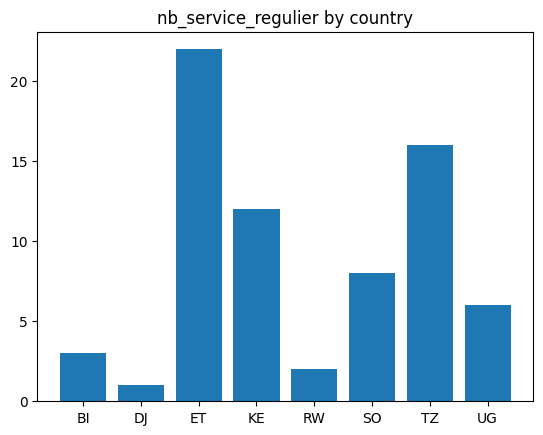

In [52]:
import matplotlib.pyplot as plt

# TODO : choisissez la colonne de 'synthese' qui illustre votre message
colonne_a_visualiser = "nb_service_regulier"

fig, ax = plt.subplots()
ax.bar(synthese["country"], synthese[colonne_a_visualiser])
ax.set_title(f"{colonne_a_visualiser} by country")
plt.show()


## B.5 — Choix du graphique (justification)

D'après le cours, quel type de graphique est recommandé pour comparer une quantité entre catégories (pays) ? *(à compléter)* Pour comparer une quantité entre catégories (ici, des pays), le cours recommande le bar chart, et plus précisément en barres horizontales

Pourquoi un pie chart, un donut chart ou un graphique 3D seraient de mauvais choix ici ? *(à compléter — justification, pas juste « parce que le cours le dit »)*   
           
 Pie / donut : inadaptés car l'œil compare mal des angles/surfaces. Avec 8 parts dont certaines proches (1, 2, 3…), distinguer Djibouti de Rwanda devient impossible. De plus un camembert sous-entend un « tout » partagé (des % d'un total), alors que mon message est une comparaison de niveaux absolus, pas une répartition.
3D : la profondeur déforme les volumes et ajoute du « chartjunk » sans information. Une 3e dimension décorative trompe la lecture des longueurs.


## B.6 — Decluttering pas à pas

Reproduisez la méthode vue en cours, une étape à la fois. Pour chaque étape, le code de l'étape précédente est repris et complété.


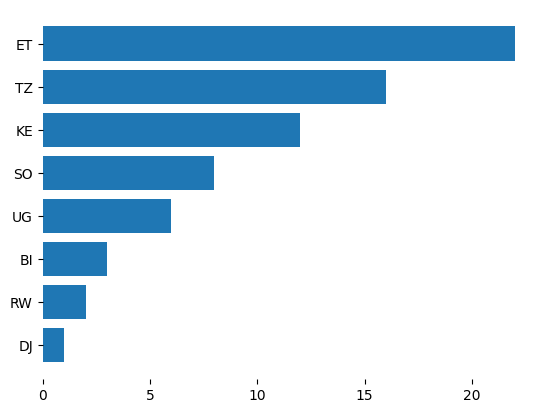

In [61]:
# Étape 1 — Passage en barres horizontales (recommandé pour les catégories, cf. cours)
#           + suppression de la bordure du graphique
# --- Étape 1 : barres horizontales + suppression des bordures ---
colonne_a_visualiser = "nb_service_regulier"
synthese_sorted = synthese.sort_values(colonne_a_visualiser)

fig, ax = plt.subplots()
# TODO : tracez un graphique en barres horizontales avec synthese_sorted (ax.barh)
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser])
# TODO : supprimez les 4 bordures (spines) du graphique
#        indice : ax.spines["..."].set_visible(False)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
plt.show()


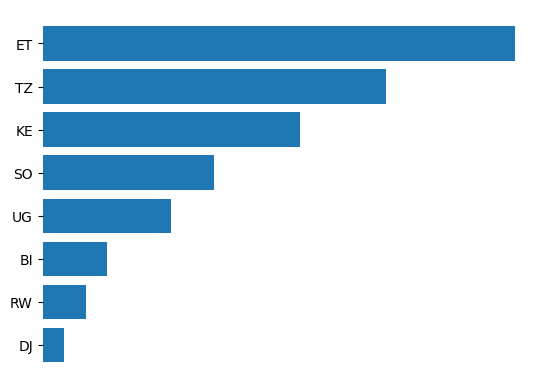

In [65]:
# Étape 2 — Nettoyer les labels d'axes (supprimer ce qui n'apporte rien)

fig, ax = plt.subplots()
# TODO : reprenez le code de l'étape 1 (barh + suppression des bordures)
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser])
# TODO : supprimez les graduations de l'axe x et son label
#        indice : ax.tick_params(axis="x", length=0), ax.set_xticklabels([]), ax.set_xlabel("")
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
    ax.tick_params(axis="x", length=0)
    ax.set_xticklabels([])
    ax.set_xlabel("")
plt.show()


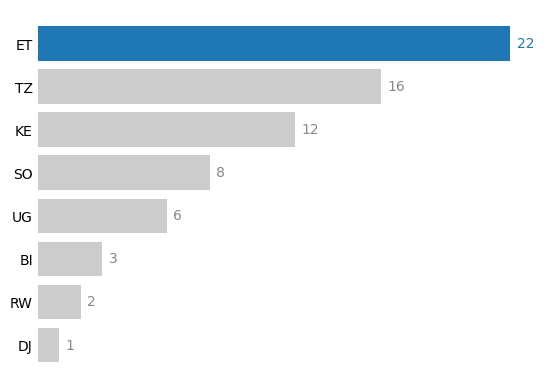

In [70]:
# Étape 3 — Labellisation directe des données + couleur intentionnelle
#           (mettre en évidence UN SEUL pays — celui de votre message — le reste en gris)

# TODO : remplacez par le pays que vous voulez mettre en évidence (cohérent avec votre storyboard)
# --- Étape 3 : labels directs + couleur intentionnelle (UN seul pays) ---
pays_a_mettre_en_evidence = "ET"   # ← une seule ligne à changer pour basculer (ex. "BI", "DJ")

couleurs = ["#1f77b4" if c == pays_a_mettre_en_evidence else "#cccccc"
            for c in synthese_sorted["country"]]

fig, ax = plt.subplots()
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser], color=couleurs)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", length=0); ax.set_xticklabels([]); ax.set_xlabel("")
ax.tick_params(axis="y", length=0)
for i, (v, c) in enumerate(zip(synthese_sorted[colonne_a_visualiser], synthese_sorted["country"])):
    ax.text(v + 0.3, i, str(int(v)), va="center",
            color="#1f77b4" if c == pays_a_mettre_en_evidence else "#888888")
plt.show()

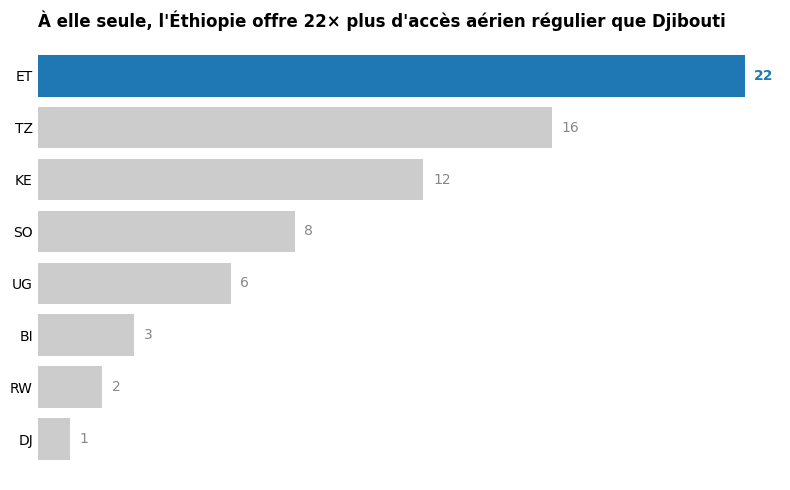

In [72]:
# Étape 4 — Version finale : titre déclaratif (l'insight, pas une description)
#           Reprend tout le code des étapes précédentes.

# TODO : remplacez par votre titre déclaratif (l'insight, formulé comme une phrase complète)
# --- Étape 4 : version finale, titre déclaratif + sauvegarde ---
titre_declaratif = "À elle seule, l'Éthiopie offre 22× plus d'accès aérien régulier que Djibouti"

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(synthese_sorted["country"], synthese_sorted[colonne_a_visualiser], color=couleurs)
for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
ax.tick_params(axis="x", length=0); ax.set_xticklabels([]); ax.set_xlabel("")
ax.tick_params(axis="y", length=0)
for i, (v, c) in enumerate(zip(synthese_sorted[colonne_a_visualiser], synthese_sorted["country"])):
    ax.text(v + 0.3, i, str(int(v)), va="center",
            color="#1f77b4" if c == pays_a_mettre_en_evidence else "#888888",
            fontweight="bold" if c == pays_a_mettre_en_evidence else "normal")
ax.set_title(titre_declaratif, fontsize=12, fontweight="bold", loc="left")
plt.tight_layout()
plt.savefig("graphique_final.png", dpi=150, bbox_inches="tight")
plt.show()


## B.7 — Message final

En Afrique de l'Est, l'accès au transport aérien régulier est profondément inégal : de 1 aéroport en service à Djibouti à 22 en Éthiopie. Derrière l'image d'une région homogène, une poignée de pôles concentre la connectivité. Pour le grand public visé par cet article, le chiffre à retenir tient en une comparaison : un facteur 22 entre voisins — point de départ de toute réflexion sur le désenclavement aérien régional.


---
## Rappel — Rendu attendu

1. Ce notebook complété (toutes les cellules `# TODO` et `*(à compléter)*` remplies).
2. `airports_clean.csv`, `synthese_pays.csv`, `graphique_final.png`.
3. `storyboard.md` (reprise de la section B.3).
4. Dépôt GitHub `mini_projet_data_dataviz_partie1` avec un historique de commits incrémental (pas un seul commit final).
